Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
  0% 0.00/22.0k [00:00<?, ?B/s]
100% 22.0k/22.0k [00:00<00:00, 65.7MB/s]
Archive:  titanic-dataset.zip
  inflating: Titanic-Dataset.csv     
Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2)

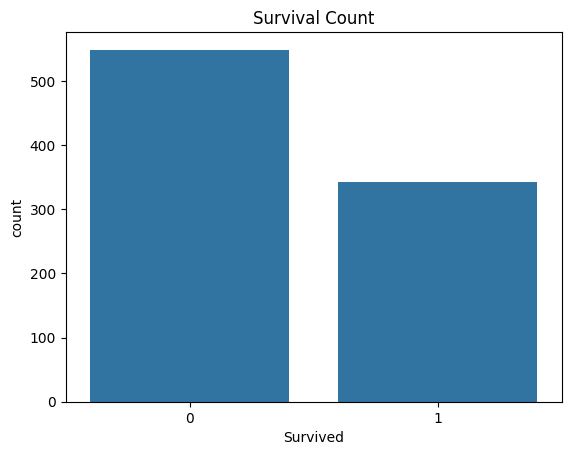

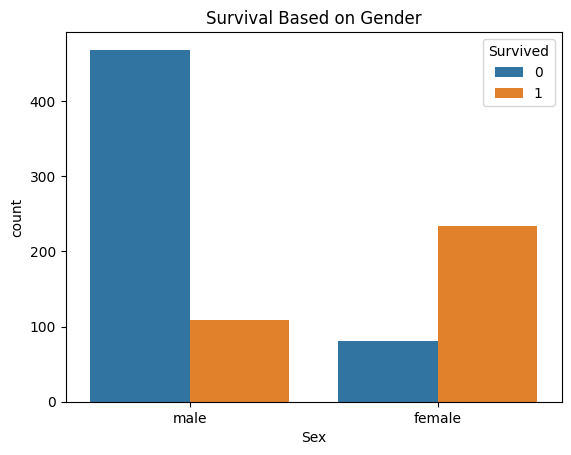

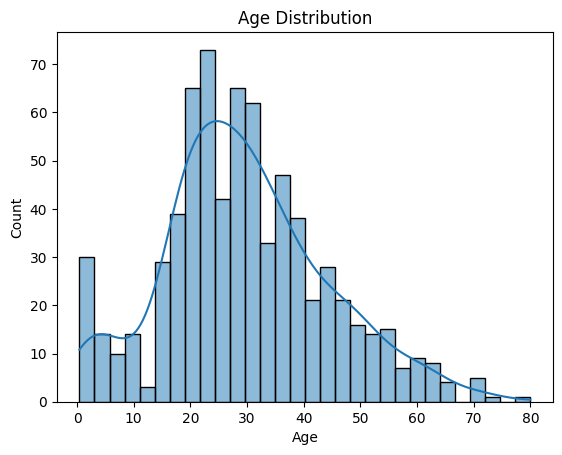

/tmp/ipython-input-1176020541.py:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Age'].fillna(df2['Age'].median(), inplace=True)
/tmp/ipython-input-1176020541.py:80: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Best Model: RandomForestClassifier(max_depth=5, n_estimators=150, random_state=42)

VALIDATION ACCURACY: 0.8156424581005587

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



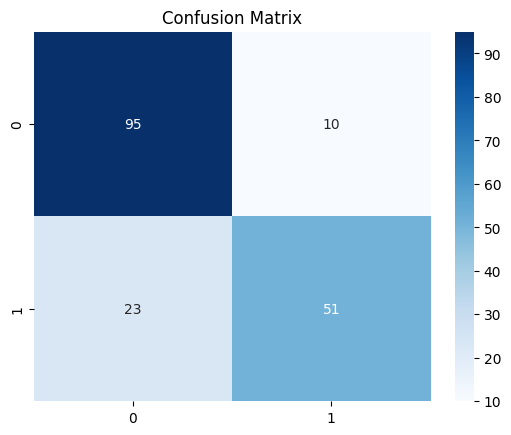

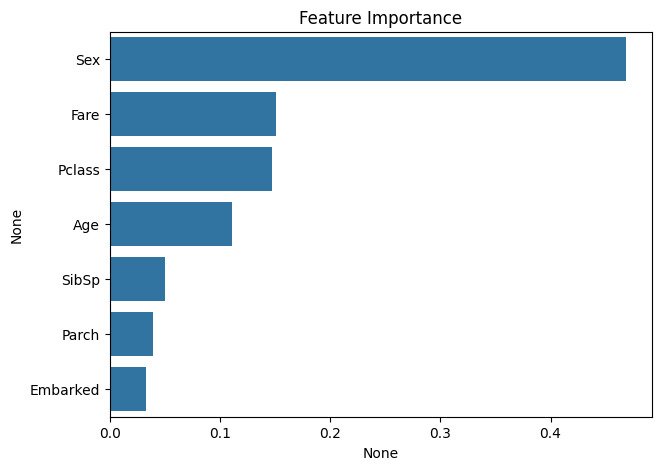


Model saved as titanic_model.joblib

Sample Prediction (0 = Died, 1 = Survived): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [2]:

# ============================================================
# TITANIC SURVIVAL PREDICTION
# ============================================================

# ------------------------------------------------------------
# STEP 1: INSTALL & SETUP KAGGLE IN COLAB
# ------------------------------------------------------------
!pip install kaggle

import os

# Create Kaggle directory
os.mkdir("/root/.kaggle")

# Upload kaggle.json (You will be prompted to select your file)
from google.colab import files
uploaded = files.upload()

# Move kaggle.json to correct folder
for fn in uploaded.keys():
    os.rename(fn, "/root/.kaggle/kaggle.json")

# Set required permissions
!chmod 600 /root/.kaggle/kaggle.json

# ------------------------------------------------------------
# STEP 2: DOWNLOAD DATASET FROM KAGGLE
# ------------------------------------------------------------
!kaggle datasets download -d yasserh/titanic-dataset

# Unzip the dataset
!unzip titanic-dataset.zip

# ------------------------------------------------------------
# STEP 3: IMPORT LIBRARIES
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# STEP 4: LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

print("Dataset Shape:", df.shape)
print(df.info())

# ------------------------------------------------------------
# STEP 5: EDA (OPTIONAL BUT GOOD FOR REPORTS)
# ------------------------------------------------------------
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival Based on Gender")
plt.show()

sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# ------------------------------------------------------------
# STEP 6: PREPROCESSING
# ------------------------------------------------------------

# Drop columns not required for prediction
df2 = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Handle missing values
df2['Age'].fillna(df2['Age'].median(), inplace=True)
df2['Embarked'].fillna(df2['Embarked'].mode()[0], inplace=True)

# Encode categorical features
le = LabelEncoder()
df2['Sex'] = le.fit_transform(df2['Sex'])
df2['Embarked'] = le.fit_transform(df2['Embarked'])

# ------------------------------------------------------------
# STEP 7: TRAIN/VALIDATION SPLIT
# ------------------------------------------------------------
X = df2.drop('Survived', axis=1)
y = df2['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# STEP 8: MODEL TRAINING (Random Forest)
# ------------------------------------------------------------
model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Model:", best_model)

# ------------------------------------------------------------
# STEP 9: EVALUATION
# ------------------------------------------------------------
y_pred = best_model.predict(X_val)

print("\nVALIDATION ACCURACY:", accuracy_score(y_val, y_pred))
print("\nCLASSIFICATION REPORT:\n", classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------------------------
# STEP 10: FEATURE IMPORTANCE
# ------------------------------------------------------------
importances = best_model.feature_importances_
features = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=features, y=features.index)
plt.title("Feature Importance")
plt.show()

# ------------------------------------------------------------
# STEP 11: SAVE MODEL (OPTIONAL)
# ------------------------------------------------------------
import joblib
joblib.dump(best_model, "titanic_model.joblib")

print("\nModel saved as titanic_model.joblib")

# ------------------------------------------------------------
# STEP 12: (OPTIONAL) PREDICT ON NEW DATA
# ------------------------------------------------------------
# Example: Predict survival of a single passenger
sample_input = X.iloc[0].values.reshape(1, -1)
sample_prediction = best_model.predict(sample_input)
print("\nSample Prediction (0 = Died, 1 = Survived):", sample_prediction[0])
